<font color='tomato'><font color="#CC3D3D"><p>
# Baseline Code (v2.0)

- `SHAP`을 이용한 Feature selection 코드 추가
- `KMeansFeaturizer`을 이용한 Feature generation 코드 추가

- shap을 통해 피처를 selection하면 feature_importance 쓰는거 보다 정확하니까 효과를 볼수 있음 근데 지금은 피처가 20개 밖에 없으니까 많이 만들어보자
- KMeansFeaturizer 피처를 자동으로 만들어줌 근데 이거 안돌아가던데 ㅋㅋ

##### Imports & Global Setting

In [1]:
import pandas as pd
import numpy as np
import os
import random
import pickle
import gzip
import gc
import re
import warnings; warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pylab as plt
from matplotlib import font_manager, rc
from tqdm import tqdm, tqdm_notebook
%matplotlib inline

from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score




import shap # v2.0부터 추가


In [2]:
VERSION = 2.0
SHAP_THRESHOLD = 0.001  # v2.0부터 추가

# 01. Data Loading

In [3]:
train = pd.read_csv('../data/train.csv', encoding='cp949')
test = pd.read_csv('../data/test.csv', encoding='cp949')

### 데이터 설명
- **패널(Panel) 데이터**
  - userID: 패널 ID
  - BIRTH: 생일(연도)
  - GENDER: 1(남자) 2(여자)
  - REGION: 거주지역
  - TYPE: 패널 구분
  - SQ1 ~ DQ7: 패널 가입 시 설문조사 데이터로 각 필드에 대한 [상세설명](https://docs.google.com/spreadsheets/d/1pY6MYTSkyHrGLmMTU8tX_xlD8fPut6Ob/edit?usp=sharing&ouid=107121563618260277687&rtpof=true&sd=true) 참조
- **설문(Survey) 데이터**
  - surveyID: 설문 ID
  - TITLE: 설문 제목
  - IR: 난이도(응답가능성, 100이 최고)
  - LOI: 설문하는데 걸리는 시간 (분단위)
  - CATEGORIES: 설문 분류
  - CPI: 패널 응답 리워드 포인트(1P~)
- **응답(Response) 데이터**
  - STATUS: 응답여부 (Target)
  - (test 데이터의) ID: submission을 식별하기 위한 ID로 사용

- SQ1 ~ DQ7 결측치도 많고 이게 응답률에 의미가 있을까?

- IR 숫자가 높을 수록 난이도 높
- LOI -시간
- CPI -리워드

* 설문응답률 설문데이터관련 피처가 중요할 것같음
* 테스트에서 ID는 인덱스의 의미
* 결측치 개많!
* 30%이하피쳐는 안썼음


# 02. Data Preprocessing

##### Clean data & derive features

In [4]:
train['surveyID'].value_counts()

surveyID
s05315    7506
s05532    5087
s05802    5037
s05633    4912
s05571    4481
          ... 
s05811       1
s05853       1
s05744       1
s05669       1
s05291       1
Name: count, Length: 1293, dtype: int64

In [5]:
train

,userID,surveyID,BIRTH,GENDER,REGION,TYPE,SQ1,SQ2,SQ3,SQ4,...,DQ4,DQ5,DQ6,DQ7,TITLE,IR,LOI,CATEGORIES,CPI,STATUS
0,p00000,s04673,1976.0,1.0,2.0,D,1.0,1976.0,1.0,"1,",...,NaN,NaN,NaN,NaN,해외-일반인의견조사(G-925574),100,13,NaN,715.0,1
1,p00000,s04675,1976.0,1.0,2.0,D,1.0,1976.0,1.0,"1,",...,NaN,NaN,NaN,NaN,해외-일반인의견조사(G-926698),100,10,NaN,550.0,1
2,p00000,s04683,1976.0,1.0,2.0,D,1.0,1976.0,1.0,"1,",...,NaN,NaN,NaN,NaN,해외---일반인-의견-조사-(DR-1379333)S,100,12,NaN,480.0,1
3,p00000,s04684,1976.0,1.0,2.0,D,1.0,1976.0,1.0,"1,",...,NaN,NaN,NaN,NaN,해외---일반인-의견-조사-(DR-8609533)S,100,12,NaN,480.0,1
4,p00000,s04686,1976.0,1.0,2.0,D,1.0,1976.0,1.0,"1,",...,NaN,NaN,NaN,NaN,해외---일반인-의견-조사-(DR-9958375)L,100,15,NaN,600.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813645,p16050,s05667,1983.0,1.0,16.0,D,1.0,1983.0,6.0,"4,",...,NaN,NaN,NaN,NaN,소비자의견조사(JY-PAS),30,9,"Smoking, Tobacco,Shopping, Retail",550.0,1
813646,p16050,s05802,1983.0,1.0,16.0,D,1.0,1983.0,6.0,"4,",...,NaN,NaN,NaN,NaN,소비자의견조사(JM-WR),5,15,"Shopping, Retail,Beverages - non alcoholic,Bev...",825.0,1
813647,p16050,s05838,1983.0,1.0,16.0,D,1.0,1983.0,6.0,"4,",...,NaN,NaN,NaN,NaN,소비자의견조사(JM-KB),50,15,"Finance, Banking",825.0,1
813648,p16050,s05899,1983.0,1.0,16.0,D,1.0,1983.0,6.0,"4,",...,NaN,NaN,NaN,NaN,일반인의견조사(GH-5),80,5,etc,275.0,1


In [6]:
# 결측값 비율이 30% 이하인 column만 사용(사용할 피처들만 출력)
features = []
for f in train.columns:
    if train[f].isnull().sum()/train.shape[0] <= 0.5:
        print(f, '\t', train[f].nunique(), '\t', train[f].isnull().sum()/train.shape[0])
        features.append(f)

userID 	 15155 	 0.0
surveyID 	 1293 	 0.0
BIRTH 	 76 	 0.0
GENDER 	 2 	 0.0
REGION 	 17 	 0.0
TYPE 	 3 	 0.0
SQ1 	 2 	 0.0009770785964481042
SQ2 	 82 	 0.0014293615190806859
SQ3 	 47 	 0.09023044306520002
SQ4 	 52 	 0.09058931973207153
SQ5 	 273 	 0.14450930989983407
SQ6 	 30 	 0.14490751551649972
SQ7 	 1234 	 0.1802556381736619
SQ8 	 1774 	 0.1831610643397038
A1 	 2768 	 0.2083279051189086
B1 	 131 	 0.21447796964296686
B2 	 120 	 0.2426792847047256
B3 	 110 	 0.24790757696798377
B4 	 715 	 0.2602888219750507
B5 	 669 	 0.26743317151109197
C1 	 1804 	 0.3316524304061943
C2 	 93 	 0.45308547901431817
C3 	 1106 	 0.4672881460087261
TITLE 	 1286 	 0.0
IR 	 42 	 0.0
LOI 	 26 	 0.0
CPI 	 43 	 0.0
STATUS 	 2 	 0.0


In [7]:
# 본인 명의로 가입한 보험의 종류 : 1/2/3/4/5/6/7/8/9/10/11/12/13/14/97 이 정상값
train.C1.value_counts()

C1
1                       68879
2                       53071
99                      52349
3                       44587
4                       26113
                        ...  
1,10,2,3,4,5,6,7,8,9        1
1,3,4,7,8                   1
1,2,4,6,7,9                 1
10,2,6,9                    1
10,3,4                      1
Name: count, Length: 1804, dtype: int64

In [8]:
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,', '5,', '6,', '7,', '8,', '9,', '10,', '11,', '12,', '13,', '14,']:
        return int(x[0])
    else:
        return 99

train.C1 = train.C1.apply(handle_profile)
test.C1 = test.C1.apply(handle_profile)

In [9]:
# 가장 자주 거래하는 은행 : 1/2/3/4/5/6/7/8/9/10/11/12/13/14/97 이 정상값
train.C2.value_counts()

C2
2            68085
99           61385
1            40073
8            37154
5            35411
             ...  
2,9              2
1,3,9            1
1,2,5            1
1,4              1
1,2,5,7,9        1
Name: count, Length: 93, dtype: int64

In [10]:
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,', '5,', '6,', '7,', '8,', '9,', '10,', '11,', '12,', '13,', '14,']:
        return int(x[0])
    else:
        return 99

train.C2 = train.C2.apply(handle_profile)
test.C2 = test.C2.apply(handle_profile)

In [11]:
# 본인이 사용하는 간편결제 서비스 전부선택: 1/2/3/4/5/6/7/8/9/10/97이 정상값
train.C3.value_counts()

C3
99               50548
2                28321
1                26889
4                23636
6                18002
                 ...  
3,7,8                1
1,2,5,7,9            1
1,2,4,6,9            1
4,5,7,9              1
1,2,3,4,5,7,8        1
Name: count, Length: 1106, dtype: int64

In [12]:
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,', '5,', '6,', '7,', '8,', '9,', '10,']:
        return int(x[0])
    else:
        return 99

train.C3 = train.C3.apply(handle_profile)
test.C3 = test.C3.apply(handle_profile)

In [13]:
# 불필요한 ID들은 제외. SQ1 ~ SQ3는 GENDER, BIRTH, REGION과 중복이어서 제외!
features.remove('userID')
features.remove('surveyID')
features.remove('STATUS')
features.remove('SQ1')
features.remove('SQ2')
features.remove('SQ3')

In [14]:
# 거주 주택 형태: 1/2/3/4/5/6/97이 정상값
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,', '5,', '6,']:
        return int(x[0])
    else:
        return 99

train.SQ4 = train.SQ4.apply(handle_profile)
test.SQ4 = test.SQ4.apply(handle_profile)

In [15]:
# 최종학력: 1/2/3/4 정상값
def handle_profile(x):
    if x in ['1', '2', '3', '4']:
        return int(x)
    elif x in ['1.0', '2.0', '3.0', '4.0']:
        return int(x[0])
    else:
        return 99

train.SQ5 = train.SQ5.apply(handle_profile)
test.SQ5 = test.SQ5.apply(handle_profile)

In [16]:
# 결혼여부: 1/2/97 정상값
def handle_profile(x):
    if x in ['1', '2']:
        return int(x)
    elif x in ['1,', '2,']:
        return int(x[0])
    else:
        return 99

train.SQ6 = train.SQ6.apply(handle_profile)
test.SQ6 = test.SQ6.apply(handle_profile)

In [17]:
# 자녀 정보: 1~16/99 정상값
value1 = pd.Series(range(1,17)).apply(lambda x: str(x)).tolist()
value2 = pd.Series(np.arange(1.0,17.0)).apply(lambda x: str(x)).tolist()
def handle_profile(x):
    if x in value1:
        return int(x)
    elif x in value2:
        return int(x[0])
    else:
        return 99

train.SQ7 = train.SQ7.apply(handle_profile)
test.SQ7 = test.SQ7.apply(handle_profile)

In [18]:
# 가족수: 1/2/3/4/5 정상값
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5']:
        return int(x)
    else:
        return 99

train.SQ8 = train.SQ8.apply(handle_profile)
test.SQ8 = test.SQ8.apply(handle_profile)

In [19]:
# 최근 구입/렌트 가전제품: 1~22/99 정상값

## 최근 구매 사실에 대해서 설문조사를 진행했을 확률이 있을까?
values = pd.Series(range(1,23)).apply(lambda x: str(x)).tolist()
def handle_profile(x):    
    if x in values:
        return int(x)
    else:
        return 99

train.A1 = train.A1.apply(handle_profile)
test.A1 = test.A1.apply(handle_profile)

In [20]:
# 휴대폰 통신망 종류: 1~8/99 정상값
def handle_profile(x):    
    if x in ['1']:
        return 2
    elif x in ['2', '3']:
        return 3
    elif x in ['4', '5', '6', '7']:
        return 4
    elif x in ['8']:
        return 5
    else:
        return 99

train.B1 = train.B1.apply(handle_profile)
test.B1 = test.B1.apply(handle_profile)

In [21]:
# 가입한 이동통신사: 1~6/97 정상값 
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6']:
        return int(x)
    else:
        return 99

train.B2 = train.B2.apply(handle_profile)
test.B2 = test.B2.apply(handle_profile)

In [22]:
# 휴대폰 브랜드: 1~7/97/99 --1등
def handle_profile(x):    
    if x in ['1', '2', '3']:
        return int(x)
    elif x in ['1,', '2,', '3,']:
        return int(x[0])
    elif x in ['99', '99,']:
        return 99
    else:
        return 4  # 기타 제조사

train.B3 = train.B3.apply(handle_profile)
test.B3 = test.B3.apply(handle_profile)

In [23]:
# 보유 스마트 기기: 1~7/97/99  --1등
def handle_profile(x):    
    if x != x :
        return 0
    elif x in ['1', '2', '3', '4', '5', '6', '7' , '99', '97']:
        return int(x)
    else:
        return 98

train.B4 = train.B4.apply(handle_profile)
test.B4 = test.B4.apply(handle_profile)

In [24]:
# 케이블TV: 1~10/97/99  --1등
def handle_profile(x):    
    if x != x :
        return 0
    elif x in ['1', '2', '3', '4' ,'5', '6', '7', '8', '9', '10']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,' ,'5,', '6,', '7,', '8,', '9,', '10,']:
        return int(x[0])
    elif x in ['99', '99,']:
        return 99
    else:
        return 4  # 기타 제조사

train.B5 = train.B5.apply(handle_profile)
test.B5 = test.B5.apply(handle_profile)

- **TITLE**


In [25]:
train.TITLE.value_counts()

TITLE
일반인의견조사(Rm-K)            7506
소비자의견조사(HJ-JJ)           5087
소비자의견조사(JM-WR)           5037
소비자의견조사(SM-OT-Pag)       4912
일반인의견조사(M-TK)            4481
                         ... 
해외-일반인의견조사(G-1003288)       1
해외-일반인의견조사(G-1004081)       1
해외-일반인의견조사(G-997511)        1
해외-일반인의견조사(G-992275)        1
해외-일반인의견조사(G-960414)        1
Name: count, Length: 1286, dtype: int64

In [26]:
train_TITLE = train.copy()
test_TITLE = test.copy()
train_TITLE.head()

,userID,surveyID,BIRTH,GENDER,REGION,TYPE,SQ1,SQ2,SQ3,SQ4,...,DQ4,DQ5,DQ6,DQ7,TITLE,IR,LOI,CATEGORIES,CPI,STATUS
0,p00000,s04673,1976.0,1.0,2.0,D,1.0,1976.0,1.0,1,...,NaN,NaN,NaN,NaN,해외-일반인의견조사(G-925574),100,13,NaN,715.0,1
1,p00000,s04675,1976.0,1.0,2.0,D,1.0,1976.0,1.0,1,...,NaN,NaN,NaN,NaN,해외-일반인의견조사(G-926698),100,10,NaN,550.0,1
2,p00000,s04683,1976.0,1.0,2.0,D,1.0,1976.0,1.0,1,...,NaN,NaN,NaN,NaN,해외---일반인-의견-조사-(DR-1379333)S,100,12,NaN,480.0,1
3,p00000,s04684,1976.0,1.0,2.0,D,1.0,1976.0,1.0,1,...,NaN,NaN,NaN,NaN,해외---일반인-의견-조사-(DR-8609533)S,100,12,NaN,480.0,1
4,p00000,s04686,1976.0,1.0,2.0,D,1.0,1976.0,1.0,1,...,NaN,NaN,NaN,NaN,해외---일반인-의견-조사-(DR-9958375)L,100,15,NaN,600.0,1


In [27]:
# Survey 제목에서 유용한 정보 추출 
# train.TITLE.value_counts()

word_counts = {}
def count_word(x): # 응답한 서베이 제목에서 한글 단어만 분리하고 빈도 계산
    if x['STATUS'] == 1:
        for w in re.sub(r'[^ ㄱ-ㅣ가-힣]', '', x['TITLE']).split():
            word_counts[w] = word_counts.get(w, 0) + 1
def score_word(x): # 빈도의 합으로 제목을 Encoding
    score = 0
    for w in re.sub(r'[^ ㄱ-ㅣ가-힣]', '', x['TITLE']).split():
        score += word_counts.get(w, 0)
    return score    
            
train.apply(count_word, axis=1)
train.TITLE = train.apply(score_word, axis=1)
test.TITLE = test.apply(score_word, axis=1)

- 제목하고 응답률 피처가 가장 중요하지 않을까,,

# 03. Feature Generation(FE_GN)

In [28]:
# 기존 컬럼 (대상자유형 일반인, 대상자유형소비자는 아님)
train.columns

Index(['userID', 'surveyID', 'BIRTH', 'GENDER', 'REGION', 'TYPE', 'SQ1', 'SQ2',
       'SQ3', 'SQ4', 'SQ5', 'SQ6', 'SQ7', 'SQ8', 'A1', 'B1', 'B2', 'B3', 'B4',
       'B5', 'C1', 'C2', 'C3', 'F1', 'F2', 'H1', 'T1', 'X1', 'X2', 'X3', 'X4',
       'DQ1', 'DQ2', 'DQ3', 'DQ4', 'DQ5', 'DQ6', 'DQ7', 'TITLE', 'IR', 'LOI',
       'CATEGORIES', 'CPI', 'STATUS'],
      dtype='object')

In [29]:
# 00. 응답률(RESRATE) 생성
res_freq = train.query('STATUS == 1').groupby('userID')['userID'].agg([('FREQ',np.size)]).reset_index()
send_freq = train.groupby('userID')['userID'].agg([('SEND',np.size)]).reset_index()

train = train.merge(res_freq, how='left').merge(send_freq, how='left')
train['RESRATE'] = train['FREQ'] / train['SEND']
del train['FREQ'], train['SEND']
test = pd.merge(test, train.drop_duplicates(subset=['userID'])[['userID', 'RESRATE']], how='left')
test['RESRATE'] = test['RESRATE'].fillna(0)
### 결측값을 이렇게 처리하는게 최선일까?

#features.extend(['RESRATE'])    --> 피처 추가는 round된 버전으로!

In [30]:
# 01. 응답률(RESRATE) 반올림한 버전 feature 생성

# RESRATE 값을 반올림하여 새로운 피처 'RESRATE'로 생성
train['RESRATE'] = train['RESRATE'].round(3)
test['RESRATE'] = test['RESRATE'].round(3)

features.extend(['RESRATE'])  # features 리스트에 새로운 피처명 추가


In [31]:
# 01-1. RESRATE_bins  (( 응답률(RESRATE) 구간화 ))
# 구간을 정의합니다. 여기서는 5개의 구간으로 분할합니다.
bins = [0, 0.25, 0.6, 0.8, 1.0]

# 각 구간에 해당하는 레이블을 정의합니다.
labels = ['1', '2', '3', '4']

# train 데이터프레임에 새로운 칼럼 'RESRATE_bins'을 추가하고, 구간화를 수행한 값으로 채웁니다.
train['RESRATE_bins'] = pd.cut(train['RESRATE'], bins=bins, labels=labels)

# 결과 확인
print(train[['RESRATE', 'RESRATE_bins']].head(10))

   RESRATE RESRATE_bins
0    0.976            4
1    0.976            4
2    0.976            4
3    0.976            4
4    0.976            4
5    0.976            4
6    0.976            4
7    0.976            4
8    0.976            4
9    0.976            4


In [32]:
train['RESRATE_bins'].value_counts()

RESRATE_bins
1    164157
2    155150
3    154146
4    139789
Name: count, dtype: int64

In [33]:
# 02. 타입별 응답률 ??타입이 뭐임 근데 (올라감)
response = train.groupby('TYPE')['STATUS'].agg([('TYPE_RES_RATE', lambda x: np.mean(x))]).reset_index()
train = train.merge(response, how='left', on='TYPE')
test = test.merge(response, how='left', on='TYPE')

features.extend(['TYPE_RES_RATE'])

In [34]:
#03시간 + 리워드  
train['시간_리워드'] = train['IR'] / train['LOI']
test['시간_리워드'] = test['IR'] / test['LOI']
features.extend(['시간_리워드'])

In [35]:
#04 -(시간+난이도)  
train['-(시간+난이도)'] = -train['IR'] - train['LOI']
test['-(시간+난이도)'] = -test['IR'] - test['LOI']
features.extend(['-(시간+난이도)'])

In [36]:
### 1등 코드
# 08-1,2,3대상자유형 생성 -- train
'''!!! Survey 제목에서 유용한 정보 추출 컬럼이랑 위치 바꾸면 오류남!!!!'''
대상지역 = np.where(train_TITLE['TITLE'].str.contains('해외'), '해외', '기타')
대상자유형_일반인 = np.where(train_TITLE['TITLE'].str.contains('일반인'), '일반인', '기타')
대상자유형_소비자 = np.where(train_TITLE['TITLE'].str.contains('소비자'), '소비자', '기타')

# 생성된 배열을 시리즈로 변환
대상지역 = pd.Series(대상지역, name='대상지역')
대상자유형_일반인 = pd.Series(대상자유형_일반인, name='대상자유형_일반인')
대상자유형_소비자 = pd.Series(대상자유형_소비자, name='대상자유형_소비자')

# 데이터프레임에 병합
train = pd.concat([train, 대상지역, 대상자유형_일반인, 대상자유형_소비자], axis=1)
features.extend(['대상지역','대상자유형_일반인', '대상자유형_소비자'])

In [37]:
### 1등 코드
# 12. 대상지역과 대상자유형 생성 --test 
'''!!! Survey 제목에서 유용한 정보 추출 컬럼이랑 위치 바꾸면 오류남!!!!'''
대상지역 = np.where(test_TITLE['TITLE'].str.contains('해외'), '해외', '기타')
대상자유형_일반인 = np.where(test_TITLE['TITLE'].str.contains('일반인'), '일반인', '기타')
대상자유형_소비자 = np.where(test_TITLE['TITLE'].str.contains('소비자'), '소비자', '기타')

# 생성된 배열을 시리즈로 변환
대상지역 = pd.Series(대상지역, name='대상지역')
대상자유형_일반인 = pd.Series(대상자유형_일반인, name='대상자유형_일반인')
대상자유형_소비자 = pd.Series(대상자유형_소비자, name='대상자유형_소비자')

# 데이터프레임에 병합
test = pd.concat([test, 대상지역, 대상자유형_일반인, 대상자유형_소비자], axis=1)


In [38]:
# 14. 패널 ID 별 획득 누적 포인트
#Points_earned = pd.DataFrame(train.query('STATUS==1').groupby('userID')['CPI'].agg([('Points_earned',np.sum)])).reset_index()
Points_earned = pd.DataFrame(train.query('STATUS==1').groupby('userID')['CPI'].agg([('Points_earned',np.sum)])).reset_index()

# 패널 ID 별 획득 평균 포인트
Points_earned_mean = pd.DataFrame(train.query('STATUS==1').groupby('userID')['CPI'].agg([('Points_earned_mean',np.mean)])).reset_index()

train = train.merge(Points_earned, how='left')
train = train.merge(Points_earned_mean, how='left')
train['Points_earned'].fillna(0, inplace = True)
train['Points_earned_mean'].fillna(0, inplace = True)

test = test.merge(Points_earned, how='left')
test = test.merge(Points_earned_mean, how='left')
test['Points_earned'].fillna(0, inplace = True)
test['Points_earned_mean'].fillna(0, inplace = True)

#features.extend(['Points_earned_mean'])

In [39]:
import pandas as pd

# 0부터 1170까지는 20씩, 1200에서 2000까지는 하나의 구간으로 설정
bin_edges = list(range(0, 1200, 20)) + [2000]

# 구간에 대한 라벨 설정
bin_labels = [f'{i}-{i+19}' for i in range(0, 1180, 20)] + ['1200-2000']

# 'Points_earned_mean' 열을 구간화하여 새로운 열로 추가
train['Points_earned_bins'] = pd.cut(train['Points_earned_mean'], bins=bin_edges, labels=bin_labels, include_lowest=True)
test['Points_earned_bins'] = pd.cut(test['Points_earned_mean'], bins=bin_edges, labels=bin_labels, include_lowest=True)

features.append('Points_earned_bins')

In [40]:
# Points_earned = pd.DataFrame(train.query('STATUS==1').groupby('userID')['CPI'].agg([('Points_earned',np.sum)])).reset_index()

# # 패널 ID 별 획득 평균 포인트
# Points_earned_mean = pd.DataFrame(train.query('STATUS==1').groupby('userID')['CPI'].agg([('Points_earned_mean',np.mean)])).reset_index()

# train = train.merge(Points_earned, how='left')
# train = train.merge(Points_earned_mean, how='left')
# train['Points_earned'].fillna(0, inplace = True)
# train['Points_earned_mean'].fillna(0, inplace = True)

# test = test.merge(Points_earned, how='left')
# test = test.merge(Points_earned_mean, how='left')
# test['Points_earned'].fillna(0, inplace = True)
# test['Points_earned_mean'].fillna(0, inplace = True)

# features.extend(['Points_earned_mean'])

In [41]:
# train['Points_earned_mean']

In [42]:
# import pandas as pd

# # 구간을 정의합니다. 여기서는 3개의 구간으로 분할합니다.
# bins = [-float('inf'), train['Points_earned_mean'].quantile(1/3), train['Points_earned_mean'].quantile(2/3), float('inf')]

# # 각 구간에 해당하는 레이블을 정의합니다.
# labels = ['하', '중', '상']

# # 'Points_earned_bins' 피처를 추가하고, 구간화된 값으로 채웁니다.
# train['Points_earned_bins'] = pd.cut(train['Points_earned_mean'], bins=bins, labels=labels)

# # 결과 확인
# print(train[['Points_earned_mean', 'Points_earned_bins']].head(10))


In [43]:
# train['Points_earned_mean'].value_counts()

In [44]:
# train['Points_earned_bins'].value_counts()

In [45]:
train.columns

Index(['userID', 'surveyID', 'BIRTH', 'GENDER', 'REGION', 'TYPE', 'SQ1', 'SQ2',
       'SQ3', 'SQ4', 'SQ5', 'SQ6', 'SQ7', 'SQ8', 'A1', 'B1', 'B2', 'B3', 'B4',
       'B5', 'C1', 'C2', 'C3', 'F1', 'F2', 'H1', 'T1', 'X1', 'X2', 'X3', 'X4',
       'DQ1', 'DQ2', 'DQ3', 'DQ4', 'DQ5', 'DQ6', 'DQ7', 'TITLE', 'IR', 'LOI',
       'CATEGORIES', 'CPI', 'STATUS', 'RESRATE', 'RESRATE_bins',
       'TYPE_RES_RATE', '시간_리워드', '-(시간+난이도)', '대상지역', '대상자유형_일반인',
       '대상자유형_소비자', 'Points_earned', 'Points_earned_mean',
       'Points_earned_bins'],
      dtype='object')

##### 끝
---

# 04. 데이터 필터링


##### 데이터 정리

In [46]:
#데이터 필터링
X_train = train[features]
X_test = test[features]
y_train = train['STATUS']

# submission을 만들 때 사용하기 위해 ID 저정
ID_test = test.ID

# 메모리 낭비를 막기위해 불필요한 데이터 삭제
del train, test 
gc.collect()

0

In [47]:
# 최종 컬럼
X_train

,BIRTH,GENDER,REGION,TYPE,SQ4,SQ5,SQ6,SQ7,SQ8,A1,...,LOI,CPI,RESRATE,TYPE_RES_RATE,시간_리워드,-(시간+난이도),대상지역,대상자유형_일반인,대상자유형_소비자,Points_earned_bins
0,1976.0,1.0,2.0,D,1,99,1,99,99,99,...,13,715.0,0.976,0.611816,7.692308,-113,해외,일반인,기타,560-579
1,1976.0,1.0,2.0,D,1,99,1,99,99,99,...,10,550.0,0.976,0.611816,10.000000,-110,해외,일반인,기타,560-579
2,1976.0,1.0,2.0,D,1,99,1,99,99,99,...,12,480.0,0.976,0.611816,8.333333,-112,해외,일반인,기타,560-579
3,1976.0,1.0,2.0,D,1,99,1,99,99,99,...,12,480.0,0.976,0.611816,8.333333,-112,해외,일반인,기타,560-579
4,1976.0,1.0,2.0,D,1,99,1,99,99,99,...,15,600.0,0.976,0.611816,6.666667,-115,해외,일반인,기타,560-579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813645,1983.0,1.0,16.0,D,4,99,1,99,99,99,...,9,550.0,0.429,0.611816,3.333333,-39,기타,기타,소비자,580-599
813646,1983.0,1.0,16.0,D,4,99,1,99,99,99,...,15,825.0,0.429,0.611816,0.333333,-20,기타,기타,소비자,580-599
813647,1983.0,1.0,16.0,D,4,99,1,99,99,99,...,15,825.0,0.429,0.611816,3.333333,-65,기타,기타,소비자,580-599
813648,1983.0,1.0,16.0,D,4,99,1,99,99,99,...,5,275.0,0.429,0.611816,16.000000,-85,기타,일반인,기타,580-599


# 05. Feature Engineering

In [48]:
# 범주형 변수와 수치형 변수를 분리
def separate_features(df):
    num_features = df.select_dtypes(include=['number']).columns.tolist()
    cat_features = df.select_dtypes(exclude=['number']).columns.tolist()
    
    return num_features, cat_features

num_features, cat_features = separate_features(X_train)

In [49]:
print(len(num_features))
print(len(cat_features))

25
5


##### 1) Impute missing values

In [50]:
# 범주형이냐 수치형이냐에 따라 다르게 처리
if len(num_features) > 0:
    imp = SimpleImputer(strategy='mean')
    X_train[num_features] = imp.fit_transform(X_train[num_features])
    X_test[num_features] = imp.transform(X_test[num_features])
if len(cat_features) > 0:  
    imp = SimpleImputer(strategy="most_frequent")
    X_train[cat_features] = imp.fit_transform(X_train[cat_features])
    X_test[cat_features] = imp.transform(X_test[cat_features])
    
X_train['GENDER'] = X_train['GENDER'].astype(int)
X_train['REGION'] = X_train['REGION'].astype(int)
X_test['GENDER'] = X_test['GENDER'].astype(int)
X_test['REGION'] = X_test['REGION'].astype(int)

##### 2) Transform features (Feature Scaling)

In [51]:
scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

##### 3) Encode categorical features

In [52]:
Oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=int)
X_train[cat_features] = Oe.fit_transform(X_train[cat_features])
X_test[cat_features] = Oe.transform(X_test[cat_features])

In [53]:
print(X_train.shape)
print(X_test.shape)

(813650, 30)
(541867, 30)


<font color="#CC3D3D"><p>
##### Feature selection using SHAP

[LightGBM] [Info] Number of positive: 316565, number of negative: 497085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029347 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 916
[LightGBM] [Info] Number of data points in the train set: 813650, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389068 -> initscore=-0.451232
[LightGBM] [Info] Start training from score -0.451232


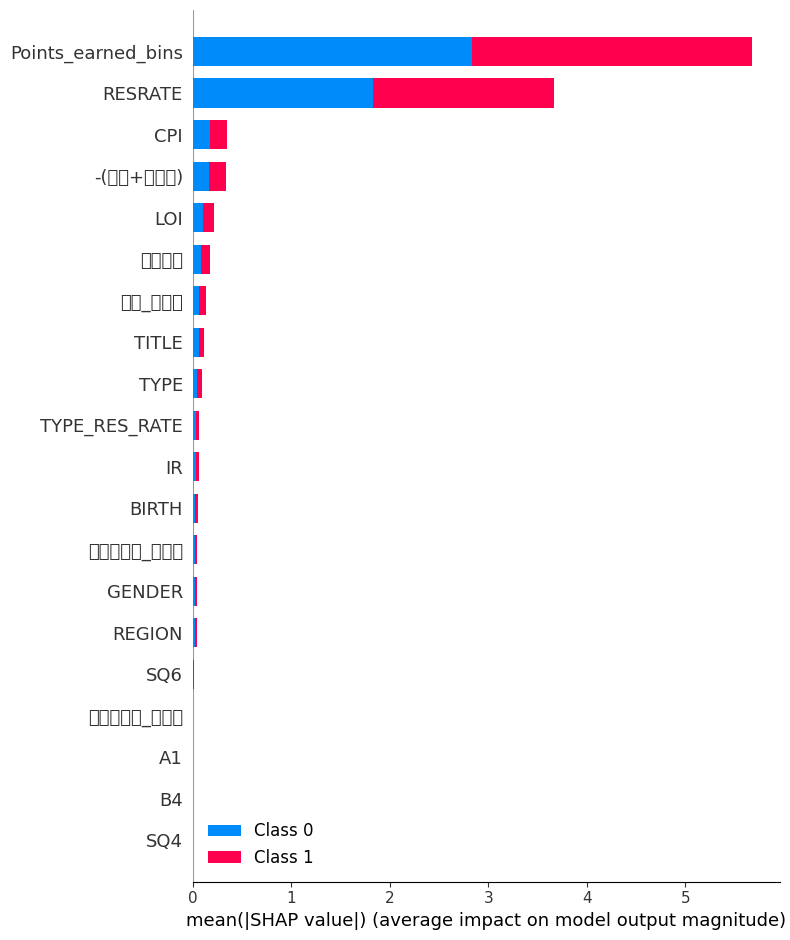

,column_name,shap_importance
29,Points_earned_bins,2.837908
22,RESRATE,1.834494
21,CPI,0.172215
25,-(시간+난이도),0.166646
20,LOI,0.107397
26,대상지역,0.087905
24,시간_리워드,0.065639
18,TITLE,0.059091
3,TYPE,0.048296
23,TYPE_RES_RATE,0.031517


In [54]:
#
# SHAP values 
#

# DF, based on which importance is checked
X_importance = X_test

# # Explain model predictions using shap library:
#LGBM쓰면 빨리 돌려지니까 이걸로 피처 추가하는 거겠지
model = LGBMClassifier(random_state=0).fit(X_train, y_train)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_importance)

# Plot summary_plot as barplot:
shap.summary_plot(shap_values, X_importance, plot_type='bar') #shap_values피처 중요도 

shap_sum = np.abs(shap_values).mean(axis=1)[1,:]
importance_df = pd.DataFrame([X_importance.columns.tolist(), shap_sum.tolist()]).T
importance_df.columns = ['column_name', 'shap_importance']
importance_df = importance_df.sort_values('shap_importance', ascending=False)
importance_df

In [55]:
# 지정된(SHAP_THRESHOLD) Shap feature 중요도 이상인 것만 선택
### 원래 34개였는데 27개됨
features_selected = importance_df.query('shap_importance > @SHAP_THRESHOLD').column_name.tolist()
X_train = X_train[features_selected]
X_test = X_test[features_selected]

print(X_train.shape)

(813650, 18)


<font color="#CC3D3D"><p>
##### Feature generation using KMeansFeaturizer

In [56]:
'''
#KMeansFeaturizer: k-means 군집분석을 실행하여 각 데이터 포인트에 가장 가까운 군집 ID를 새로운 feature로 반환  
   
from featurizer import KMeansFeaturizer  # featurizer_module은 실제 모듈 이름이다.

 #KMeansFeaturizer 클래스를 사용하는 코드
#이하 코드에서 featurizer 객체 사용

kmf_hint = KMeansFeaturizer(k=10, target_scale=5, one_hot=False, random_state=0).fit(X_train)

train_cluster_features = kmf_hint.transform(X_train)
test_cluster_features = kmf_hint.transform(X_test)

X_train = pd.concat([X_train, pd.Series(train_cluster_features, name='CLUSTER')], axis=1)
X_test = pd.concat([X_test, pd.Series(test_cluster_features, name='CLUSTER')], axis=1)'''

"\n#KMeansFeaturizer: k-means 군집분석을 실행하여 각 데이터 포인트에 가장 가까운 군집 ID를 새로운 feature로 반환  \n   \nfrom featurizer import KMeansFeaturizer  # featurizer_module은 실제 모듈 이름이다.\n\n #KMeansFeaturizer 클래스를 사용하는 코드\n#이하 코드에서 featurizer 객체 사용\n\nkmf_hint = KMeansFeaturizer(k=10, target_scale=5, one_hot=False, random_state=0).fit(X_train)\n\ntrain_cluster_features = kmf_hint.transform(X_train)\ntest_cluster_features = kmf_hint.transform(X_test)\n\nX_train = pd.concat([X_train, pd.Series(train_cluster_features, name='CLUSTER')], axis=1)\nX_test = pd.concat([X_test, pd.Series(test_cluster_features, name='CLUSTER')], axis=1)"

# 피처 상관관계

In [57]:
import pandas as pd



# 상관 행렬 계산
correlation_matrix = X_train.corr().abs()

# 상관 계수의 임계값 설정 (예: 0.6)
threshold = 0.7

# 상관 관계가 높은 피처들을 담을 리스트
high_corr_features = []

# 상관 관계가 임계값 이상인 피처들을 찾아 리스트에 추가
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if correlation_matrix.iloc[i, j] > threshold:
            colname = correlation_matrix.columns[i]
            high_corr_features.append((correlation_matrix.columns[j], colname, correlation_matrix.iloc[i, j]))

print("임계값 {} 이상의 상관 관계를 가진 피처들:".format(threshold))
for feature_pair in high_corr_features:
    print("피처 '{}', '{}', 상관 계수: {}".format(feature_pair[0], feature_pair[1], feature_pair[2]))


임계값 0.7 이상의 상관 관계를 가진 피처들:
피처 'CPI', 'LOI', 상관 계수: 0.8869273130500693
피처 '-(시간+난이도)', '대상지역', 상관 계수: 0.8944071073138269
피처 '-(시간+난이도)', 'TITLE', 상관 계수: 0.8765363813182195
피처 '대상지역', 'TITLE', 상관 계수: 0.9885627244608717
피처 'TYPE', 'TYPE_RES_RATE', 상관 계수: 0.7857327593983031
피처 '-(시간+난이도)', 'IR', 상관 계수: 0.9890095343426556
피처 '대상지역', 'IR', 상관 계수: 0.8875743447894421
피처 'TITLE', 'IR', 상관 계수: 0.8692979489533739
피처 '대상지역', '대상자유형_일반인', 상관 계수: 0.7072339336609718
피처 'TITLE', '대상자유형_일반인', 상관 계수: 0.7585161560016086
피처 '대상자유형_소비자', '대상자유형_일반인', 상관 계수: 0.8456771098099154


In [58]:
X_train.columns

Index(['Points_earned_bins', 'RESRATE', 'CPI', '-(시간+난이도)', 'LOI', '대상지역',
       '시간_리워드', 'TITLE', 'TYPE', 'TYPE_RES_RATE', 'IR', 'BIRTH', '대상자유형_소비자',
       'GENDER', 'REGION', 'SQ6', '대상자유형_일반인', 'A1'],
      dtype='object')

In [59]:
X_train.columns

Index(['Points_earned_bins', 'RESRATE', 'CPI', '-(시간+난이도)', 'LOI', '대상지역',
       '시간_리워드', 'TITLE', 'TYPE', 'TYPE_RES_RATE', 'IR', 'BIRTH', '대상자유형_소비자',
       'GENDER', 'REGION', 'SQ6', '대상자유형_일반인', 'A1'],
      dtype='object')

<font color="#CC3D3D"><p>
##### Save preprocessed data

- 전처리 계속 할거면 피클로 저장 하면 데이터 많으면힘드니까 데이터 압축해서저장

In [60]:
'''#
# 추후 사용을 위해 전처리된 데이터 압축해서 저장
#

with gzip.open('data_preprocessed.zip', 'wb') as f:
    pickle.dump([X_train, y_train, X_test, ID_test, cat_features, num_features], f)

# load and uncompress
#with gzip.open('data_preprocessed.zip','rb') as f:
#    X_train, y_train, X_test, ID_test, cat_features, num_features = pickle.load(f)'''

"#\n# 추후 사용을 위해 전처리된 데이터 압축해서 저장\n#\n\nwith gzip.open('data_preprocessed.zip', 'wb') as f:\n    pickle.dump([X_train, y_train, X_test, ID_test, cat_features, num_features], f)\n\n# load and uncompress\n#with gzip.open('data_preprocessed.zip','rb') as f:\n#    X_train, y_train, X_test, ID_test, cat_features, num_features = pickle.load(f)"

# 06. Model building

- LGBM

In [61]:
model_lgbm = LGBMClassifier(n_estimators=2000,objective='binary', metric='binary_error', random_state=44)
lgbm_pred = np.zeros((X_test.shape[0]))
accuracy_list = []
list_lgbm = []

threshold = 0.5 
spl = 5

kf = KFold(n_splits=spl, shuffle=True, random_state=42)

for tr_idx, val_idx in tqdm(kf.split(X_train, y_train)):
    tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    val_x, val_y = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    model_lgbm.fit(tr_x, tr_y, eval_metric = 'accuracy')
    pred = model_lgbm.predict(val_x)

    accuracy = accuracy_score(val_y, pred)
    accuracy_list.append(accuracy)
    print(accuracy)
    
    sub_pred = np.array(model_lgbm.predict_proba(X_test)[:, 1])  # X_test에 대한 예측값 구하기
    lgbm_pred += sub_pred

# 최종 예측값 구하기 (5-fold의 평균값 사용)
final_predictions_lgbm = (lgbm_pred / spl >= 0.5).astype(int)
print(final_predictions_lgbm)
print(f'{model_lgbm.__class__.__name__}의 fold 평균 Accuracy는 {np.mean(accuracy_list)}')

0it [00:00, ?it/s]

[LightGBM] [Info] Number of positive: 253249, number of negative: 397671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013744 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 787
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389063 -> initscore=-0.451252
[LightGBM] [Info] Start training from score -0.451252
0.8606771953542678


1it [00:15, 15.78s/it]

[LightGBM] [Info] Number of positive: 253255, number of negative: 397665
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 781
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389072 -> initscore=-0.451213
[LightGBM] [Info] Start training from score -0.451213
0.859595649234929


2it [00:32, 16.44s/it]

...

[LightGBM] [Info] Number of positive: 253073, number of negative: 397847
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013044 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 787
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.388793 -> initscore=-0.452390
[LightGBM] [Info] Start training from score -0.452390
0.8603084864499477


4it [01:03, 15.76s/it]

[LightGBM] [Info] Number of positive: 253186, number of negative: 397734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014941 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 785
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.388966 -> initscore=-0.451659
[LightGBM] [Info] Start training from score -0.451659
0.8590671664720703


5it [01:18, 15.80s/it]

[1 1 1 ... 0 0 1]
LGBMClassifier의 fold 평균 Accuracy는 0.8600098322374485


- XGB

In [62]:
from xgboost import XGBClassifier
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# 최적의 하이퍼파라미터 설정
best_params = {
    'n_estimators': 1146,
    'max_depth': 9,
    'learning_rate': 0.02534583366384355,
    'subsample': 0.85,
    'colsample_bytree': 0.9,
    'gamma': 0.03967425666846014,
    'min_child_weight': 4
}

model_xgb = XGBClassifier(**best_params, eval_metrics='error', objective='binary:logistic', random_state=0, verbose=200)
xgb_pred = np.zeros((X_test.shape[0]))
accuracy_list = []
threshold = 0.5
spl = 5

kf = KFold(n_splits=spl, shuffle=True, random_state=42)

for tr_idx, val_idx in tqdm(kf.split(X_train, y_train)):
    tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    val_x, val_y = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    model_xgb.fit(tr_x, tr_y)
    pred = model_xgb.predict(val_x)

    accuracy = accuracy_score(val_y, pred)
    accuracy_list.append(accuracy)
    print(accuracy)
    
    sub_pred = np.array(model_xgb.predict_proba(X_test)[:, 1])  # X_test에 대한 예측값 구하기
    xgb_pred += sub_pred

# 최종 예측값 구하기 (5-fold의 평균값 사용)
final_predictions_xgb = (xgb_pred / spl >= 0.5).astype(int)
print(final_predictions_xgb)
print(f'{model_xgb.__class__.__name__}의 fold 평균 Accuracy는 {np.mean(accuracy_list)}')

0it [00:00, ?it/s]

0.8611503717814786


1it [00:08,  8.32s/it]

0.8599705032876543


2it [00:16,  8.34s/it]

...

0.8609291464388865


4it [00:33,  8.35s/it]

0.8593498432987157


5it [00:41,  8.38s/it]

[1 1 1 ... 0 0 1]
XGBClassifier의 fold 평균 Accuracy는 0.8604559700116757


- CAT

In [63]:
model_cb = CatBoostClassifier(eval_metric= 'Accuracy',loss_function = "CrossEntropy", random_state=0, verbose = 200)
lgbm_pred = np.zeros((X_test.shape[0]))
accuracy_list = []
list_lgbm = []

threshold = 0.5 
spl = 5

kf = KFold(n_splits=spl, shuffle=True, random_state=42)

for tr_idx, val_idx in tqdm(kf.split(X_train, y_train)):
    tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    val_x, val_y = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    model_cb.fit(tr_x, tr_y)
    pred = model_cb.predict(val_x)

    accuracy = accuracy_score(val_y, pred)
    accuracy_list.append(accuracy)
    print(accuracy)
    
    sub_pred = np.array(model_cb.predict_proba(X_test)[:, 1])  # X_test에 대한 예측값 구하기
    lgbm_pred += sub_pred

# 최종 예측값 구하기 (5-fold의 평균값 사용)
final_predictions_cb = (lgbm_pred / spl >= 0.5).astype(int)
print(final_predictions_cb)
print(f'{model_cb.__class__.__name__}의 fold 평균 Accuracy는 {np.mean(accuracy_list)}')

0it [00:00, ?it/s]

0:	learn: 0.8343606	total: 90.1ms	remaining: 1m 30s
200:	learn: 0.8532923	total: 3.16s	remaining: 12.5s
400:	learn: 0.8564555	total: 6.21s	remaining: 9.28s
600:	learn: 0.8578151	total: 9.27s	remaining: 6.15s
800:	learn: 0.8587107	total: 12.3s	remaining: 3.07s
999:	learn: 0.8594267	total: 15.4s	remaining: 0us
0.858637006083697


1it [00:15, 15.93s/it]

0:	learn: 0.8343867	total: 37.6ms	remaining: 37.6s
200:	learn: 0.8535289	total: 3.1s	remaining: 12.3s
400:	learn: 0.8566260	total: 6.17s	remaining: 9.21s
600:	learn: 0.8580302	total: 9.23s	remaining: 6.13s
800:	learn: 0.8588214	total: 12.3s	remaining: 3.06s


2it [00:31, 15.87s/it]

...

0:	learn: 0.8349951	total: 37ms	remaining: 36.9s
200:	learn: 0.8527976	total: 3.09s	remaining: 12.3s
400:	learn: 0.8563756	total: 6.16s	remaining: 9.19s
600:	learn: 0.8575785	total: 9.2s	remaining: 6.11s
800:	learn: 0.8585156	total: 12.3s	remaining: 3.05s


4it [01:03, 15.80s/it]

999:	learn: 0.8591332	total: 15.3s	remaining: 0us
0.8591470534013397
0:	learn: 0.8353699	total: 35.4ms	remaining: 35.4s
200:	learn: 0.8535995	total: 3.09s	remaining: 12.3s
400:	learn: 0.8567919	total: 6.14s	remaining: 9.17s
600:	learn: 0.8577659	total: 9.19s	remaining: 6.1s
800:	learn: 0.8588029	total: 12.3s	remaining: 3.05s
999:	learn: 0.8595373	total: 15.3s	remaining: 0us
0.8579856203527315


5it [01:19, 15.83s/it]

[1 1 1 ... 0 0 0]
CatBoostClassifier의 fold 평균 Accuracy는 0.8585595772137896


In [64]:
# 다섯 가지 모델의 예측값을 더하고 5로 나누어 평균 계산
avg_predictions = (final_predictions_lgbm + final_predictions_xgb + final_predictions_cb) / 3

# 평균값을 기준으로 0 또는 1로 예측
threshold = 0.5  # 임계값 설정
final_predictions = np.where(avg_predictions >= threshold, 1, 0)

print(final_predictions)

[1 1 1 ... 0 0 1]


In [65]:
len(final_predictions)

541867

In [66]:
t = pd.Timestamp.now()
fname = f"oof_hardvoting6{t.month:02}{t.day:02}{t.hour:02}{t.minute:02}.csv"
pd.DataFrame({'ID': ID_test, 'STATUS': final_predictions}).to_csv(fname, index=False)
print(f"'{fname}' is ready to submit.")

'oof_hardvoting612190623.csv' is ready to submit.


In [67]:
X_test.shape[0]

541867